# Monte Carlo Methods, n-step TD, and TD(λ)

**Goal:** Understand how to learn value functions and optimal policies without a model of the environment's dynamics, transitioning from full-episode Monte Carlo methods to step-by-step Temporal Difference learning, and finally unifying them with n-step returns and eligibility traces.

**Prerequisites:** Markov Decision Processes (MDPs), Dynamic Programming (Policy Evaluation, Value Iteration).

**Theory Link:** [theory.md](./theory.md) — secondary reference: Reinforcement Learning: An Introduction (Sutton & Barto), Chapters 5, 6, 7, and 12.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)

plt.rcParams["figure.dpi"] = 90

## 1. Problem Setup — WHY

Dynamic Programming requires a perfect model of the environment ($p(s', r | s, a)$). What if we don't have it? We must learn from *experience*.

- **Monte Carlo (MC):** Learn from complete episodes. We play until the end, see the total reward (return), and update our estimates. No bootstrapping.
- **Temporal Difference (TD):** Learn from incomplete episodes. We take a step, observe the reward, and *bootstrap* our current estimate of the next state's value to update the current state's value.
- **The Spectrum:** There is a continuum between MC and TD. We can wait 1 step (TD(0)), $n$ steps ($n$-step TD), or until the end of the episode (MC).
- **TD(λ):** An elegant unification using eligibility traces, allowing us to compute a weighted average of all $n$-step returns efficiently.

## 2. Mathematical Core — WHAT

**1. Monte Carlo Return:**
The total discounted reward from time $t$ to the end of the episode $T$:
$$G_t = R_{t+1} + \gamma R_{t+2} + ... + \gamma^{T-t-1}R_T$$

**2. TD(0) Target:**
Bootstrap using the value estimate of the next state:
$$G_t^{(1)} = R_{t+1} + \gamma V(S_{t+1})$$

**3. $n$-step Return:**
Wait $n$ steps, sum the rewards, and bootstrap from the $n$-th state:
$$G_t^{(n)} = \sum_{k=0}^{n-1} \gamma^k R_{t+k+1} + \gamma^n V(S_{t+n})$$

**4. $\lambda$-return (Forward View):**
A weighted average of all $n$-step returns, parameterized by $\lambda \in [0, 1]$:
$$G_t^\lambda = (1-\lambda)\sum_{n=1}^{T-t-1} \lambda^{n-1} G_t^{(n)} + \lambda^{T-t-1} G_t$$

**5. Eligibility Traces (Backward View):**
A mechanism to efficiently implement TD($\lambda$) incrementally. It keeps track of recently visited states:
$$e_t(s) = \gamma\lambda e_{t-1}(s) + \mathbb{1}(S_t = s)$$
Update rule: $V(s) \leftarrow V(s) + \alpha \delta_t e_t(s)$ where $\delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)$.

## 3. Solution Method — HOW

- **First-visit MC prediction:** Average returns only from the *first* visit to state $s$ in each episode. Unbiased estimate of $V(s)$.
- **Every-visit MC prediction:** Average returns from *every* visit to state $s$. Slightly biased but often easier to implement and lower variance.
- **MC control with $\epsilon$-greedy:** Evaluate $Q(s, a)$, then improve the policy by choosing the argmax $Q(s, a)$ with probability $1-\epsilon$, and a random action with probability $\epsilon$ to ensure exploration.
- **TD($\lambda$) with eligibility traces:** Keep an eligibility trace vector $E$. On each step, decay all traces by $\gamma\lambda$, increment the trace for the current state, and update all states proportional to their trace and the current TD error.

## 4. Implementation — BUILD

First, we define two environments: `CliffWalking` for control and `RandomWalk` for prediction.

In [2]:
class CliffWalking:
    """
    4x12 grid. Start=(3,0), Goal=(3,11).
    Bottom row (3,1)-(3,10) is the cliff: stepping on it gives -100 and resets to start.
    Every other step gives -1. Actions: Up/Right/Down/Left.
    """
    def __init__(self):
        self.shape = (4, 12)
        self.start = (3, 0)
        self.goal = (3, 11)
        self.cliff = [(3, i) for i in range(1, 11)]
        # Actions: 0:Up, 1:Right, 2:Down, 3:Left
        self.actions = [(-1, 0), (0, 1), (1, 0), (0, -1)]
        self.action_names = ['U', 'R', 'D', 'L']
        self.state = self.start
        
    def reset(self):
        self.state = self.start
        return self.state
        
    def step(self, action_idx):
        action = self.actions[action_idx]
        new_r = max(0, min(self.shape[0] - 1, self.state[0] + action[0]))
        new_c = max(0, min(self.shape[1] - 1, self.state[1] + action[1]))
        next_state = (new_r, new_c)
        
        if next_state in self.cliff:
            return self.start, -100, False
        
        if next_state == self.goal:
            return next_state, -1, True
            
        self.state = next_state
        return next_state, -1, False


class RandomWalk:
    """
    1D chain with 5 non-terminal states A-E (indices 1-5).
    Terminal states at 0 (left) and 6 (right).
    Starts at C (index 3).
    Rewards: 0 on all transitions except into right terminal state (6) which gives +1.
    """
    def __init__(self):
        self.num_states = 7
        self.start = 3
        self.terminal_states = [0, 6]
        
    def reset(self):
        self.state = self.start
        return self.state
        
    def step(self, action_idx):
        # 0 = left, 1 = right
        if action_idx == 0:
            self.state -= 1
        else:
            self.state += 1
            
        reward = 1 if self.state == 6 else 0
        done = self.state in self.terminal_states
        
        return self.state, reward, done

Now we implement the agents: Monte Carlo, $n$-step TD, and TD($\lambda$). We also implement SARSA and Q-Learning for control comparisons.

In [3]:
class MCPrediction:
    """First-visit Monte Carlo for estimating V(s) under a given policy."""
    def __init__(self, num_states, gamma=1.0):
        self.V = np.zeros(num_states)
        self.returns_sum = np.zeros(num_states)
        self.returns_count = np.zeros(num_states)
        self.gamma = gamma
        
    def evaluate(self, episodes):
        for episode in episodes:
            states, rewards = episode
            G = 0
            visited = set()
            for t in reversed(range(len(states))):
                state = states[t]
                if t < len(rewards):
                    G = self.gamma * G + rewards[t]
                if state not in visited:
                    visited.add(state)
                    self.returns_sum[state] += G
                    self.returns_count[state] += 1
                    self.V[state] = self.returns_sum[state] / self.returns_count[state]

class NStepTD:
    """n-step TD prediction."""
    def __init__(self, num_states, n, alpha, gamma=1.0):
        self.V = np.zeros(num_states)
        self.n = n
        self.alpha = alpha
        self.gamma = gamma
        
    def evaluate_episode(self, episode):
        states, rewards = episode
        T = len(states) - 1  # Total time steps (terminal state is at index T)
        for tau in range(T):
            # tau is the state whose value is being updated
            # Calculate n-step return
            end_idx = min(tau + self.n, T)
            G = 0
            for i in range(tau, end_idx):
                G += (self.gamma ** (i - tau)) * rewards[i]
                
            if tau + self.n < T:
                G += (self.gamma ** self.n) * self.V[states[tau + self.n]]
                
            self.V[states[tau]] += self.alpha * (G - self.V[states[tau]])

class TDLambda:
    """TD(λ) with eligibility traces for prediction (backward view)."""
    def __init__(self, num_states, alpha, gamma, lam):
        self.V = np.zeros(num_states)
        self.alpha = alpha
        self.gamma = gamma
        self.lam = lam
        
    def evaluate_episode(self, states, rewards):
        E = np.zeros_like(self.V)
        for t in range(len(states) - 1):
            s = states[t]
            next_s = states[t+1]
            r = rewards[t]
            
            delta = r + self.gamma * self.V[next_s] - self.V[s]
            E[s] += 1  # Accumulating trace
            
            for state in range(len(self.V)):
                self.V[state] += self.alpha * delta * E[state]
                E[state] *= self.gamma * self.lam

class SarsaControl:
    """SARSA (on-policy TD control)."""
    def __init__(self, shape, num_actions, alpha=0.1, gamma=1.0, epsilon=0.1):
        self.Q = np.zeros(shape + (num_actions,))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.num_actions = num_actions
        
    def choose_action(self, state, rng):
        if rng.random() < self.epsilon:
            return rng.integers(self.num_actions)
        return np.argmax(self.Q[state])
        
    def train(self, env, n_episodes, rng):
        returns = []
        for _ in range(n_episodes):
            state = env.reset()
            action = self.choose_action(state, rng)
            done = False
            total_reward = 0
            while not done:
                next_state, reward, done = env.step(action)
                next_action = self.choose_action(next_state, rng)
                total_reward += reward
                
                sa = state + (action,)
                next_sa = next_state + (next_action,)
                
                td_target = reward + (0 if done else self.gamma * self.Q[next_sa])
                td_error = td_target - self.Q[sa]
                self.Q[sa] += self.alpha * td_error
                
                state, action = next_state, next_action
            returns.append(total_reward)
        return returns

class QLearningControl:
    """Q-Learning (off-policy TD control)."""
    def __init__(self, shape, num_actions, alpha=0.1, gamma=1.0, epsilon=0.1):
        self.Q = np.zeros(shape + (num_actions,))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.num_actions = num_actions
        
    def choose_action(self, state, rng):
        if rng.random() < self.epsilon:
            return rng.integers(self.num_actions)
        return np.argmax(self.Q[state])
        
    def train(self, env, n_episodes, rng):
        returns = []
        for _ in range(n_episodes):
            state = env.reset()
            done = False
            total_reward = 0
            while not done:
                action = self.choose_action(state, rng)
                next_state, reward, done = env.step(action)
                total_reward += reward
                
                sa = state + (action,)
                
                best_next_q = 0 if done else np.max(self.Q[next_state])
                td_target = reward + self.gamma * best_next_q
                td_error = td_target - self.Q[sa]
                self.Q[sa] += self.alpha * td_error
                
                state = next_state
            returns.append(total_reward)
        return returns

## 5. Comparison
Comparing value estimates on Random Walk.

True V:  [0.167 0.333 0.5   0.667 0.833]
MC V:    [0.242 0.397 0.53  0.671 0.815]
TD(0) V: [0.132 0.387 0.571 0.735 0.825]


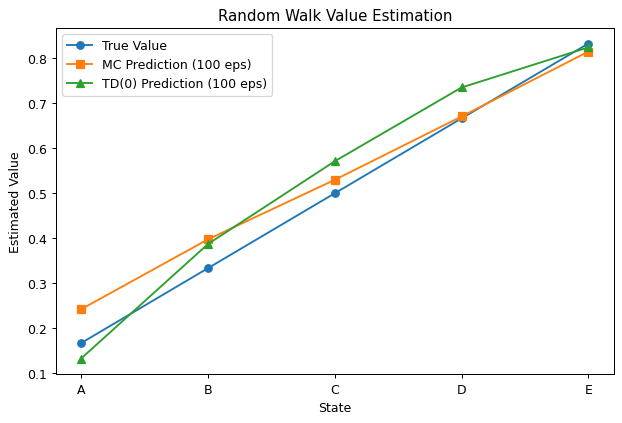

In [4]:
def generate_random_walk_episode(env, rng):
    states = [env.reset()]
    rewards = []
    done = False
    while not done:
        action = rng.integers(2)
        next_s, r, done = env.step(action)
        states.append(next_s)
        rewards.append(r)
    return states, rewards

true_V = np.array([0, 1/6, 2/6, 3/6, 4/6, 5/6, 0])
rw_env = RandomWalk()

mc = MCPrediction(num_states=7)
td0 = TDLambda(num_states=7, alpha=0.1, gamma=1.0, lam=0.0)

# Init V with 0.5 for non-terminals, 0 for terminals
mc.V[1:6] = 0.5
td0.V[1:6] = 0.5

for _ in range(100):
    episode = generate_random_walk_episode(rw_env, rng)
    mc.evaluate([episode])
    td0.evaluate_episode(*episode)

print("True V: ", np.round(true_V[1:6], 3))
print("MC V:   ", np.round(mc.V[1:6], 3))
print("TD(0) V:", np.round(td0.V[1:6], 3))

# Check true values
assert np.allclose(true_V[1:6], [1/6, 2/6, 3/6, 4/6, 5/6]), "True values must be exact"

plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), true_V[1:6], marker='o', label='True Value')
plt.plot(range(1, 6), mc.V[1:6], marker='s', label='MC Prediction (100 eps)')
plt.plot(range(1, 6), td0.V[1:6], marker='^', label='TD(0) Prediction (100 eps)')
plt.xlabel('State')
plt.ylabel('Estimated Value')
plt.xticks(range(1, 6), ['A', 'B', 'C', 'D', 'E'])
plt.title('Random Walk Value Estimation')
plt.legend()
plt.show()

## 6. Experiments and Failures — VERIFY

### 1. Bias-Variance Tradeoff (MC vs TD(0))
MC has zero bias but high variance (updates from end of episode). TD(0) is biased by initial estimates but has lower variance (updates after one step).

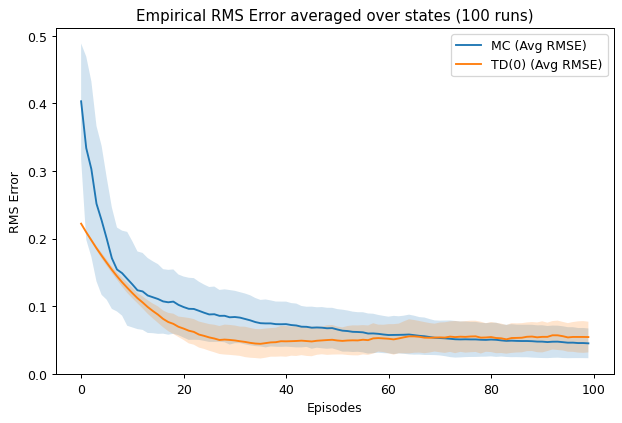

In [5]:
def compute_rmse(V, true_V):
    return np.sqrt(np.mean((V[1:6] - true_V[1:6])**2))

n_runs = 100
n_episodes = 100

mc_errors = np.zeros((n_runs, n_episodes))
td0_errors = np.zeros((n_runs, n_episodes))

for run in range(n_runs):
    mc_agent = MCPrediction(num_states=7)
    td0_agent = TDLambda(num_states=7, alpha=0.1, gamma=1.0, lam=0.0)
    mc_agent.V[1:6] = 0.5
    td0_agent.V[1:6] = 0.5
    
    for ep in range(n_episodes):
        episode = generate_random_walk_episode(rw_env, rng)
        mc_agent.evaluate([episode])
        td0_agent.evaluate_episode(*episode)
        
        mc_errors[run, ep] = compute_rmse(mc_agent.V, true_V)
        td0_errors[run, ep] = compute_rmse(td0_agent.V, true_V)

plt.figure(figsize=(8, 5))
plt.plot(np.mean(mc_errors, axis=0), label='MC (Avg RMSE)')
plt.plot(np.mean(td0_errors, axis=0), label='TD(0) (Avg RMSE)')
plt.fill_between(range(n_episodes), 
                 np.mean(mc_errors, axis=0) - np.std(mc_errors, axis=0), 
                 np.mean(mc_errors, axis=0) + np.std(mc_errors, axis=0), alpha=0.2)
plt.fill_between(range(n_episodes), 
                 np.mean(td0_errors, axis=0) - np.std(td0_errors, axis=0), 
                 np.mean(td0_errors, axis=0) + np.std(td0_errors, axis=0), alpha=0.2)
plt.xlabel('Episodes')
plt.ylabel('RMS Error')
plt.title('Empirical RMS Error averaged over states (100 runs)')
plt.legend()
plt.show()

### 2. $n$-step sweep
Evaluating different $n$-step returns on the Random Walk.

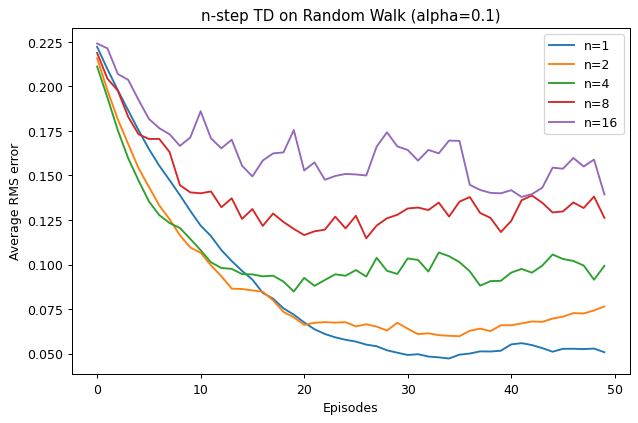

In [6]:
ns = [1, 2, 4, 8, 16] # 16 is effectively MC for this small walk
alpha = 0.1
n_runs = 50
n_episodes = 50

avg_errors = {n: np.zeros(n_episodes) for n in ns}

for n in ns:
    errors = np.zeros((n_runs, n_episodes))
    for run in range(n_runs):
        agent = NStepTD(num_states=7, n=n, alpha=alpha, gamma=1.0)
        agent.V[1:6] = 0.5
        for ep in range(n_episodes):
            episode = generate_random_walk_episode(rw_env, rng)
            agent.evaluate_episode(episode)
            errors[run, ep] = compute_rmse(agent.V, true_V)
    avg_errors[n] = np.mean(errors, axis=0)

plt.figure(figsize=(8, 5))
for n in ns:
    plt.plot(avg_errors[n], label=f'n={n}')
plt.xlabel('Episodes')
plt.ylabel('Average RMS error')
plt.title(f'n-step TD on Random Walk (alpha={alpha})')
plt.legend()
plt.show()

### 3. $\lambda$ sweep
TD($\lambda$) bridges TD(0) and MC.

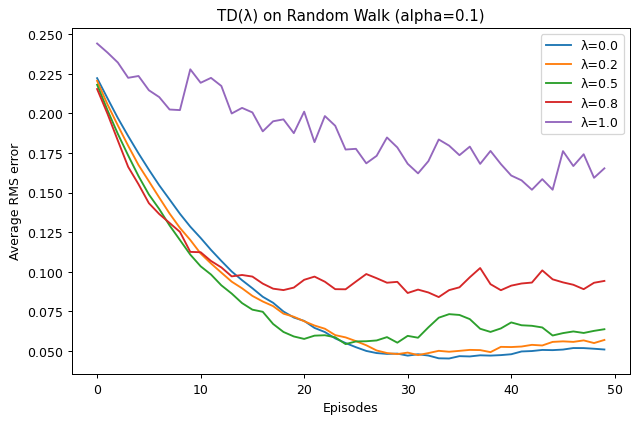

In [7]:
lams = [0.0, 0.2, 0.5, 0.8, 1.0]
alpha = 0.1
n_runs = 50
n_episodes = 50

avg_errors_lam = {lam: np.zeros(n_episodes) for lam in lams}

for lam in lams:
    errors = np.zeros((n_runs, n_episodes))
    for run in range(n_runs):
        agent = TDLambda(num_states=7, alpha=alpha, gamma=1.0, lam=lam)
        agent.V[1:6] = 0.5
        for ep in range(n_episodes):
            episode = generate_random_walk_episode(rw_env, rng)
            agent.evaluate_episode(*episode)
            errors[run, ep] = compute_rmse(agent.V, true_V)
    avg_errors_lam[lam] = np.mean(errors, axis=0)

plt.figure(figsize=(8, 5))
for lam in lams:
    plt.plot(avg_errors_lam[lam], label=f'λ={lam}')
plt.xlabel('Episodes')
plt.ylabel('Average RMS error')
plt.title(f'TD(λ) on Random Walk (alpha={alpha})')
plt.legend()
plt.show()

### 4. CliffWalking: SARSA vs Q-Learning
SARSA (on-policy) learns the safe path because its $\epsilon$-greedy exploration penalizes walking near the cliff. Q-Learning (off-policy) learns the optimal path but falls in frequently during training due to exploration.

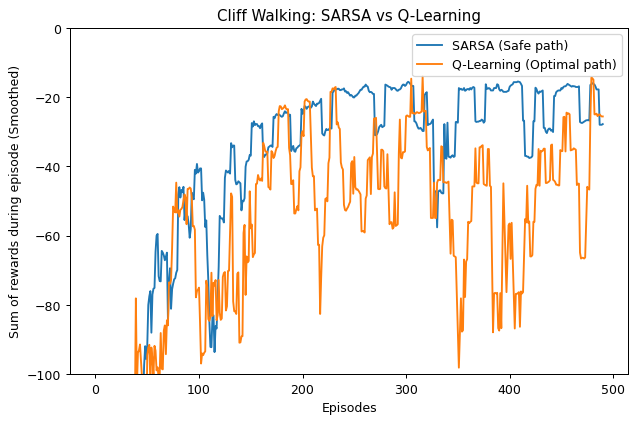

In [8]:
cliff_env = CliffWalking()
n_eps = 500

sarsa = SarsaControl(shape=cliff_env.shape, num_actions=4, alpha=0.1, gamma=1.0, epsilon=0.1)
qlearn = QLearningControl(shape=cliff_env.shape, num_actions=4, alpha=0.1, gamma=1.0, epsilon=0.1)

sarsa_returns = sarsa.train(cliff_env, n_eps, rng)
q_returns = qlearn.train(cliff_env, n_eps, rng)

# Smooth returns
def moving_average(x, w=10):
    return np.convolve(x, np.ones(w), 'valid') / w

plt.figure(figsize=(8, 5))
plt.plot(moving_average(sarsa_returns, 10), label='SARSA (Safe path)')
plt.plot(moving_average(q_returns, 10), label='Q-Learning (Optimal path)')
plt.ylim(-100, 0)
plt.xlabel('Episodes')
plt.ylabel('Sum of rewards during episode (Smoothed)')
plt.title('Cliff Walking: SARSA vs Q-Learning')
plt.legend()
plt.show()

### 5. Failure: MC's dependence on complete returns
If an episode never terminates (e.g. the agent gets stuck in a loop and the environment has no time limit), Monte Carlo methods hang forever: they require the episode to end before updating values, while TD methods update incrementally after each step.

The same dependence is measurable when episodes do terminate but data is scarce. Below we repeat a short training run (10 episodes) across 50 seeded repetitions and measure the empirical bias and variance of the MC and TD(0) estimates of $V(A)$ on the Random Walk: MC is nearly unbiased but has high variance, while TD(0) has low variance but a large bias toward its 0.5 initialization.

In [9]:
# Measured failure mode: with few episodes, MC's full-return estimates have far higher
# variance than TD(0)'s bootstrapped estimates, which instead carry an initialization bias.
n_reps = 50
n_episodes_short = 10
target_state = 1  # state A, true value 1/6

mc_estimates = np.zeros(n_reps)
td_estimates = np.zeros(n_reps)
for rep in range(n_reps):
    rep_rng = np.random.default_rng(SEED + rep)  # independent seeded repetition
    mc_rep = MCPrediction(num_states=7)
    td_rep = TDLambda(num_states=7, alpha=0.1, gamma=1.0, lam=0.0)
    mc_rep.V[1:6] = 0.5
    td_rep.V[1:6] = 0.5
    for _ in range(n_episodes_short):
        episode = generate_random_walk_episode(rw_env, rep_rng)  # same episodes for both agents
        mc_rep.evaluate([episode])
        td_rep.evaluate_episode(*episode)
    mc_estimates[rep] = mc_rep.V[target_state]
    td_estimates[rep] = td_rep.V[target_state]

mc_var, td_var = mc_estimates.var(), td_estimates.var()
mc_bias = abs(mc_estimates.mean() - true_V[target_state])
td_bias = abs(td_estimates.mean() - true_V[target_state])

print(f"V(A) over {n_reps} repetitions of {n_episodes_short} episodes (true value {true_V[target_state]:.4f}):")
print(f"  MC   : mean={mc_estimates.mean():.4f}  bias={mc_bias:.4f}  variance={mc_var:.5f}")
print(f"  TD(0): mean={td_estimates.mean():.4f}  bias={td_bias:.4f}  variance={td_var:.5f}")

# Measured relationship — deterministic given the fixed repetition seeds
# (variance ratio ~13x; TD bias ~0.17 vs MC bias ~0.002).
assert mc_var > 3.0 * td_var, "MC variance should exceed TD(0) variance by a clear margin"
assert td_bias > mc_bias + 0.05, "TD(0) should carry a large initialization bias; MC is nearly unbiased"
print("Measured: MC = high variance / low bias, TD(0) = low variance / high bias.")

V(A) over 50 repetitions of 10 episodes (true value 0.1667):
  MC   : mean=0.1691  bias=0.0024  variance=0.02279
  TD(0): mean=0.3339  bias=0.1672  variance=0.00173
Measured: MC = high variance / low bias, TD(0) = low variance / high bias.


## 7. Connections & Takeaways

- **MC Returns:** While basic MC is high variance, the concept of calculating full returns is foundational for modern Policy Gradient methods like REINFORCE.
- **TD(0):** Forms the basis of Q-Learning, allowing for off-policy control and incremental learning.
- **TD($\lambda$):** Bridges the gap between MC and TD(0). 
- **Eligibility Traces:** A precursor to Generalized Advantage Estimation (GAE), which is heavily used in state-of-the-art algorithms like PPO (Proximal Policy Optimization) to balance bias and variance in advantage estimation.